# McGill COMP551 – Mini-Project 3  
## Odd-One-Out (< 25k parameters)


### High-level idea

The model:

1. encodes each of the 5 images with the **same small CNN**,  
2. for each candidate image, compares it to the **prototype of the 4 others**,  
3. computes a learned **relation score** saying how likely this image is to be the odd one out.

This is still lightweight, but much stronger than using only a raw Euclidean distance to the mean.

## Step 1 — Imports

In [1]:
import os, copy, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


## Step 2 — Load data

In [2]:
x = np.load('datasets/x_train.npy')        # (3000, 5, 32, 32)
y = np.load('datasets/y_train.npy')        # (3000,)
x_test      = np.load('datasets/x_test.npy')
x_test_half = x_test[:1000]
y_test_half = np.load('datasets/y_test.npy')
print('x_train:', x.shape)
print('y_train:', y.shape, 'labels:', np.unique(y))

x_train: (3000, 5, 32, 32)
y_train: (3000,) labels: [0 1 2 3 4]


## Step 3 — Train/val split

In [3]:
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)
print("Train split:", x_train.shape, y_train.shape)
print("Val split:  ", x_val.shape, y_val.shape)

Train split: (2400, 5, 32, 32) (2400,)
Val split:   (600, 5, 32, 32) (600,)


## Step 4 — Dataset

Augmentations are applied to the whole group consistently.

In [4]:
def augment_group(imgs):
    """Consistent spatial augmentation across all 5 images in a group.
    imgs: (5, 1, 32, 32)
    KEY: same transform applied to all 5 so the odd one stays odd for
    the right reasons, not because it was flipped differently.
    """
    if torch.rand(1).item() < 0.5:
        imgs = torch.flip(imgs, dims=[-1])    # horizontal flip
    if torch.rand(1).item() < 0.5:
        imgs = torch.flip(imgs, dims=[-2])    # vertical flip
    rot = torch.randint(0, 4, (1,)).item()    # 0/90/180/270
    if rot == 1:
        imgs = torch.flip(imgs.transpose(-2, -1), dims=[-1])
    elif rot == 2:
        imgs = torch.flip(imgs, dims=[-1, -2])
    elif rot == 3:
        imgs = torch.flip(imgs.transpose(-2, -1), dims=[-2])
    return imgs


class OddDataset(Dataset):
    def __init__(self, x, y=None, permute=False, augment=False):
        self.x       = torch.tensor(x, dtype=torch.float32).unsqueeze(2)  # (N,5,1,32,32)
        self.y       = None if y is None else torch.tensor(y, dtype=torch.long)
        self.permute = permute
        self.augment = augment

    def __len__(self): 
        return len(self.x)

    def __getitem__(self, idx):
        imgs  = self.x[idx].clone()   # (5, 1, 32, 32)

        if self.augment:
            imgs = augment_group(imgs)

        if self.y is None:
            return imgs

        label = self.y[idx]
        if self.permute:
            perm  = torch.randperm(5)
            imgs  = imgs[perm]
            label = torch.where(perm == label)[0][0]

        return imgs, label

## Step 5 — Model

### Architecture summary

- A shared CNN encoder turns each image into a compact embedding.
- For each candidate image \(i\), we build a representation using:
  - the candidate embedding,
  - the mean embedding of the other 4 images,
  - absolute difference,
  - elementwise product,
  - distance statistics to the 4 other images (mean / max / min).
- A small MLP outputs a score.  
- The image with the **largest score** is predicted as the odd one out.

This is still a **single model**, and it remains below the 25k parameter limit.

# Additions
### 1. L2-normalized embeddings
After the encoder fc layer, normalize each embedding vector to unit length.
All embeddings now live on a sphere — distances are always in [0, 2].
The model can't cheat by using embedding magnitude.

### 2. Group spread feature
For candidate i, compute the mean pairwise distance among the OTHER 4 images.
This tells the scorer: 'the baseline spread of this group is X'.
Without it, a distance of 0.5 to the prototype could mean very different things
depending on whether the group is tightly clustered or widely spread.
With it, the scorer can ask: 'is the candidate unusually far RELATIVE to group spread?'

In [5]:
class Encoder(nn.Module):
    def __init__(self, emb_dim=24):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=4, padding=1),
            nn.BatchNorm2d(12),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(12, 24, kernel_size=4, padding=1),
            nn.BatchNorm2d(24),
            nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 32, kernel_size=4, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(32, emb_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.fc(x)
        return F.normalize(x, dim=1)   # L2 normalize onto unit sphere

class OddOneOutModel(nn.Module):
    def __init__(self, emb_dim=24, hidden_dim=48):
        super().__init__()
        self.encoder = Encoder(emb_dim=emb_dim)

        # zi, proto, others_std, abs_diff, prod = 5 * emb_dim
        # dist stats (mean, max, min, var)       = 4
        # group_spread                           = 1
        feat_dim = emb_dim * 5 + 4 + 1

        self.scorer = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.15),          
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x: (B, 5, 1, 32, 32)
        Z = torch.stack([self.encoder(x[:, i]) for i in range(5)], dim=1)  # (B,5,D)

        scores = []
        for i in range(5):
            zi     = Z[:, i]
            others = torch.cat([Z[:, :i], Z[:, i+1:]], dim=1)   # (B,4,D)

            proto      = others.mean(dim=1)                      # (B,D)
            others_std = others.std(dim=1, unbiased=False)       # (B,D)
            abs_diff   = (zi - proto).abs()                      # (B,D)
            prod       = zi * proto                              # (B,D)

            # Distances from candidate to each of the 4 others
            pair_dists = torch.norm(
                others - zi.unsqueeze(1), dim=2
            )  # (B,4)

            # Mean pairwise distance among the 4 others themselves
            # Captures baseline spread of the group
            # added group_dists and group_spread to capture how tightly clustered the 4 others are
            group_dists = []
            for a in range(4):
                for b in range(a+1, 4):
                    group_dists.append(
                        torch.norm(others[:, a] - others[:, b], dim=1)
                    )
            group_spread = torch.stack(group_dists, dim=1).mean(dim=1, keepdim=True)  # (B,1)
            # Added var
            dist_stats = torch.stack([
                pair_dists.mean(dim=1),
                pair_dists.max(dim=1).values,
                pair_dists.min(dim=1).values,
                pair_dists.var(dim=1, unbiased=False),
            ], dim=1)  # (B,4)

            feat  = torch.cat([zi, proto, others_std, abs_diff, prod, dist_stats, group_spread], dim=1)
            scores.append(self.scorer(feat).squeeze(1))

        return torch.stack(scores, dim=1)   # (B,5)

In [6]:
model = OddOneOutModel().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')
assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

Total trainable parameters: 24,181


## Step 6 — Training

Notes:
- We use **cross-entropy** with a small amount of **label smoothing**.
- We use **AdamW**.
- We keep the checkpoint with the **best validation accuracy**.
- Early stopping is based on validation accuracy.
- max_epochs: 75, patience: 15  

In [7]:
def make_loaders(x_tr, y_tr, x_v, y_v, batch_size=128):
    train_ds = OddDataset(x_tr, y_tr, permute=True,  augment=True)
    val_ds   = OddDataset(x_v,  y_v,  permute=False, augment=False)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    )


def evaluate(model, loader):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            targets.extend(yb.numpy())
    return accuracy_score(targets, preds)


def train_model(
    x_tr, y_tr, x_v, y_v,
    seed=42, lr=5e-3, weight_decay=5e-4,
    batch_size=128, max_epochs=75, patience=15
):
    set_seed(seed)
    model = OddOneOutModel().to(device)
    train_loader, val_loader = make_loaders(x_tr, y_tr, x_v, y_v, batch_size)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    best_val, best_state, best_epoch, wait = -1., None, 0, 0
    history = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        loss_sum, correct, total = 0., 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * xb.size(0)
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += yb.size(0)

        scheduler.step()
        train_acc = correct / total
        val_acc   = evaluate(model, val_loader)

        history.append({'epoch': epoch, 'train_loss': loss_sum/total,
                        'train_acc': train_acc, 'val_acc': val_acc})
        print(f'Epoch {epoch:02d} | loss={loss_sum/total:.4f} | '
              f'train={train_acc:.4f} | val={val_acc:.4f}')

        if val_acc > best_val:
            best_val, best_state, best_epoch, wait = val_acc, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= patience:
                print('Early stopping triggered.')
                break

    model.load_state_dict(best_state)
    return model, history, best_val, best_epoch

## Step 7 — Train on val split

Epoch 01 | loss=1.5781 | train=0.2983 | val=0.2833
Epoch 02 | loss=1.5574 | train=0.3079 | val=0.3117
Epoch 03 | loss=1.5380 | train=0.3304 | val=0.3283
Epoch 04 | loss=1.5169 | train=0.3517 | val=0.2767
Epoch 05 | loss=1.4829 | train=0.3875 | val=0.3300
Epoch 06 | loss=1.4402 | train=0.4108 | val=0.3800
Epoch 07 | loss=1.3551 | train=0.4617 | val=0.4717
Epoch 08 | loss=1.2255 | train=0.5325 | val=0.4733
Epoch 09 | loss=1.1354 | train=0.5933 | val=0.5583
Epoch 10 | loss=1.0251 | train=0.6663 | val=0.6433
Epoch 11 | loss=0.9033 | train=0.7267 | val=0.6483
Epoch 12 | loss=0.7747 | train=0.7900 | val=0.7700
Epoch 13 | loss=0.6838 | train=0.8329 | val=0.7700
Epoch 14 | loss=0.6514 | train=0.8350 | val=0.7967
Epoch 15 | loss=0.6260 | train=0.8467 | val=0.7900
Epoch 16 | loss=0.6048 | train=0.8504 | val=0.7717
Epoch 17 | loss=0.5883 | train=0.8562 | val=0.8067
Epoch 18 | loss=0.5629 | train=0.8617 | val=0.8067
Epoch 19 | loss=0.5481 | train=0.8696 | val=0.8083
Epoch 20 | loss=0.5390 | train=

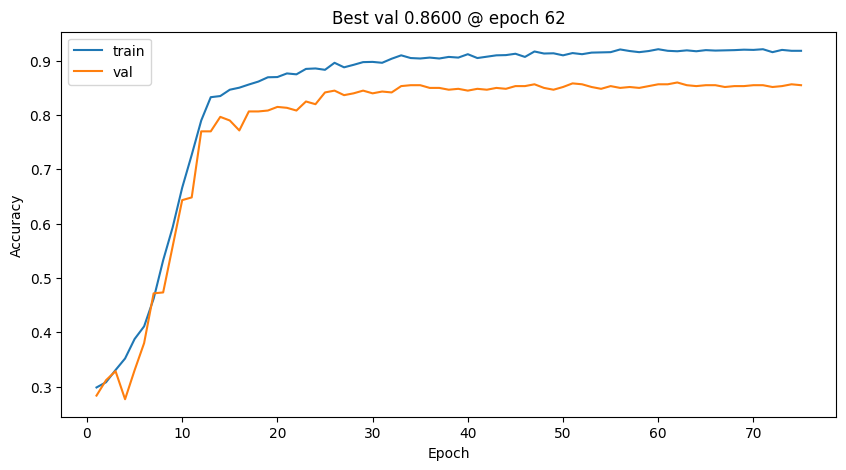


Train/val gap at best epoch: 0.0583


In [8]:
model, history, best_val_acc, best_epoch = train_model(
    x_train, y_train, x_val, y_val
)
print(f'\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}')

history_df = pd.DataFrame(history)
plt.figure(figsize=(10, 5))
plt.plot(history_df.epoch, history_df.train_acc, label='train')
plt.plot(history_df.epoch, history_df.val_acc,   label='val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Best val {best_val_acc:.4f} @ epoch {best_epoch}')
plt.legend(); plt.show()

# DIAGNOSTIC: print the train/val gap
# A gap > 0.10 means we're still overfitting
# A gap < 0.05 means training is well-regularized
final_train = history_df.iloc[-1]['train_acc']
print(f'\nTrain/val gap at best epoch: {final_train - best_val_acc:.4f}')


## Step 8 — Retrain on all 3000 examples


After choosing the configuration, we train **one single final model** on the full training set.

Because we no longer keep a validation split here, we train for a fixed number of epochs:
`best_epoch`


This keeps the final pipeline simple and compliant.

In [ ]:
def train_final_model(x_full, y_full, seed=42, epochs=None,
                      lr=5e-3, weight_decay=5e-4, batch_size=128):
    set_seed(seed)
    model  = OddOneOutModel().to(device)
    loader = DataLoader(
        OddDataset(x_full, y_full, permute=True, augment=True),
        batch_size=batch_size, shuffle=True
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, correct, total = 0., 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * xb.size(0)
            correct  += (logits.argmax(1) == yb).sum().item()
            total    += yb.size(0)
        scheduler.step()
        print(f'Final epoch {epoch:02d} | loss={loss_sum/total:.4f} | acc={correct/total:.4f}')

    return model


final_model = train_final_model(
    x, y,
    seed=42,
    epochs=best_epoch-1, # we can be a bit more aggressive with epochs here since we're training on more data, and the val curve was still improving at best_epoch
    lr=5e-3,
    weight_decay=5e-4,
    batch_size=128
)

Final epoch 01 | loss=1.5769 | acc=0.3000
Final epoch 02 | loss=1.5558 | acc=0.3150
Final epoch 03 | loss=1.5411 | acc=0.3347
Final epoch 04 | loss=1.5397 | acc=0.3317
Final epoch 05 | loss=1.5155 | acc=0.3510
Final epoch 06 | loss=1.4217 | acc=0.3983
Final epoch 07 | loss=1.2938 | acc=0.4907
Final epoch 08 | loss=1.1370 | acc=0.6057
Final epoch 09 | loss=0.9667 | acc=0.7003
Final epoch 10 | loss=0.8796 | acc=0.7323
Final epoch 11 | loss=0.7968 | acc=0.7713
Final epoch 12 | loss=0.6877 | acc=0.8233
Final epoch 13 | loss=0.6435 | acc=0.8393
Final epoch 14 | loss=0.6182 | acc=0.8430
Final epoch 15 | loss=0.5848 | acc=0.8533
Final epoch 16 | loss=0.5772 | acc=0.8580
Final epoch 17 | loss=0.5582 | acc=0.8733
Final epoch 18 | loss=0.5459 | acc=0.8767
Final epoch 19 | loss=0.5498 | acc=0.8717
Final epoch 20 | loss=0.5554 | acc=0.8770
Final epoch 21 | loss=0.5490 | acc=0.8787
Final epoch 22 | loss=0.5255 | acc=0.8957
Final epoch 23 | loss=0.5318 | acc=0.8863
Final epoch 24 | loss=0.5232 | acc

## Step 10 — TTA inference

TTA with permutations + spatial augmentations.
n_tta=30 gives stable predictions — increasing beyond this has diminishing returns.

In [10]:
def predict_tta(model, x_data, batch_size=128, n_tta=30):
    model.eval()
    x_t = torch.tensor(x_data, dtype=torch.float32).unsqueeze(2)  
    N   = len(x_t)
    accum = torch.zeros(N, 5)

    with torch.no_grad():
        for _ in range(n_tta):
            perm     = torch.randperm(5)
            inv_perm = torch.argsort(perm)
            x_perm   = x_t[:, perm].clone()

            # Random spatial aug (same for all 5)
            if torch.rand(1).item() < 0.5:
                x_perm = torch.flip(x_perm, dims=[-1])
            if torch.rand(1).item() < 0.5:
                x_perm = torch.flip(x_perm, dims=[-2])
            rot = torch.randint(0, 4, (1,)).item()
            if rot == 1:
                x_perm = torch.flip(x_perm.transpose(-2,-1), dims=[-1])
            elif rot == 2:
                x_perm = torch.flip(x_perm, dims=[-1,-2])
            elif rot == 3:
                x_perm = torch.flip(x_perm.transpose(-2,-1), dims=[-2])

            all_logits = []
            for start in range(0, N, batch_size):
                xb     = x_perm[start:start+batch_size].to(device)
                logits = model(xb)[:, inv_perm]   # un-permute
                all_logits.append(logits.cpu())

            accum += torch.cat(all_logits, dim=0)

    return accum.argmax(dim=1).numpy()


def predict_standard(model, x_data, batch_size=128):
    model.eval()
    ds     = OddDataset(x_data, permute=False, augment=False)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    preds  = []
    with torch.no_grad():
        for xb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
    return np.array(preds)


std_preds = predict_standard(final_model, x_test_half)
tta_preds = predict_tta(final_model,      x_test_half, n_tta=30)

print(f'Standard: {accuracy_score(y_test_half, std_preds)*100:.2f}%')
print(f'TTA n=30: {accuracy_score(y_test_half, tta_preds)*100:.2f}%')

Standard: 75.00%
TTA n=30: 76.20%


## Step 11 — Generate the CSV for Kaggle

The CSV must be created on the **entire** test set (`x_test`) and use the required column names:
- `Id`
- `Category`

In [12]:
all_preds = predict_tta(final_model, x_test, n_tta=30)
pd.DataFrame({'Id': np.arange(len(all_preds)), 'Category': all_preds})\
  .to_csv('submission_v4.csv', index=False)
print('Saved submission_v4.csv')

Saved submission_v4.csv
